<a href="https://colab.research.google.com/github/ngahi/acceptance/blob/main/tp1_nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Classification

Text Classification is relevant in many industrial settings, for example:
- spam detection
- sentiment analysis
- hate speech detection

There are also several theoretical NLP problems that are framed as classification, such as Natural Language Inference.

For this practical work, we will study the detection of automatically generated text (more specifically, automatically generated research papers), based on the work of [Liyanage et al. 2022 "A Benchmark Corpus for the Detection of Automatically Generated Text in Academic Publications"](https://aclanthology.org/2022.lrec-1.501)

> Automatic text generation based on neural language models has achieved performance levels that make the generated text almost indistinguishable from those written by humans. Despite the value that text generation can have in various applications, it can also be employed for malicious tasks. The diffusion of such practices represent a threat to the quality of academic publishing. To address these problems, we propose in this paper two datasets comprised of artificially generated research content: a completely synthetic dataset and a partial text substitution dataset. In the first case, the content is completely generated by the GPT-2 model after a short prompt extracted from original papers. The partial or hybrid dataset is created by replacing several sentences of abstracts with sentences that are generated by the Arxiv-NLP model. We evaluate the quality of the datasets comparing the generated texts to aligned original texts using fluency metrics such as BLEU and ROUGE. The more natural the artificial texts seem, the more difficult they are to detect and the better is the benchmark. We also evaluate the difficulty of the task of distinguishing original from generated text by using state-of-the-art classification models.

# Imports

Note: you're not allowed to use any other libraries than these

In [1]:
from pathlib import Path
import re
from collections import Counter
import matplotlib.pyplot as plt

# N.B. we use torch for consistency with the rest of the class
# but will not use GPUs nor autograd here,
# everything could be done in numpy
import torch

# Data
We will use the Hybrid subset of Liyanage et al. in which some sentences of human-written abstracts where replaced by automatically-generated text.

There are no train-test split provided in the paper but we keep 80% to train and 20% to test, following Liyanage et al.

In [2]:
!wget https://github.com/vijini/GeneratedTextDetection/archive/refs/heads/main.zip

!unzip main.zip

--2025-10-23 02:44:34--  https://github.com/vijini/GeneratedTextDetection/archive/refs/heads/main.zip
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/vijini/GeneratedTextDetection/zip/refs/heads/main [following]
--2025-10-23 02:44:34--  https://codeload.github.com/vijini/GeneratedTextDetection/zip/refs/heads/main
Resolving codeload.github.com (codeload.github.com)... 140.82.112.9
Connecting to codeload.github.com (codeload.github.com)|140.82.112.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘main.zip’

main.zip                [  <=>               ] 800.25K  2.15MB/s    in 0.4s    

2025-10-23 02:44:35 (2.15 MB/s) - ‘main.zip’ saved [819461]

Archive:  main.zip
ab034465f857a93212a894fe598edb749345b6ff
   creating: GeneratedTextDetection-main/
  inflating: Gene

In [3]:
root = Path("GeneratedTextDetection-main/Dataset/Hybrid_AbstractDataset")

train_texts, train_labels, test_texts, test_labels = [], [], [], []
for path in root.glob("*.txt"):
    with open(path, 'rt') as file:
        text = file.read()
    label = int(path.name.endswith("generatedAbstract.txt"))
    doc_id = int(path.name.split("_")[0].split(".")[-1])
    if doc_id < 10522:
        test_texts.append(text)
        test_labels.append(label)
    else:
        train_texts.append(text)
        train_labels.append(label)

In [4]:
train_labels, test_labels = torch.tensor(train_labels), torch.tensor(test_labels)

In [5]:
len(train_texts), len(train_labels), len(test_texts), len(test_labels)

(160, 160, 40, 40)

In [6]:
train_texts[0]

'\ufeffWe present a method for the generation of Midi files of piano music. The method models the right and left hands using two networks, where the left hand is conditioned on the right hand. This way, the melody is generated before the harmony. The Midi is represented in a way that is invariant to the musical scale, and the melody is represented, for the purpose of conditioning the harmony, by the content of each bar, viewed as a chord. Finally, notes are added randomly, based on this chord representation, in order to enrich the generated audio. Our experiments show a significant improvement over the state of the art for training on such datasets, and demonstrate the contribution of each of the novel components.'

In [7]:
train_labels[0]

tensor(0)

In [8]:
train_texts[10]

'\ufeffNeural networks leverage both causal and correlation-based relationships in data to learn models that optimize a given performance criterion, such as classification accuracy. This results in learned models that may not necessarily reflect the true causal relationships between input and output. When domain priors of causal relationships are available at the time of training, it is essential that a neural network model maintains these relationships as causal, even as it learns to optimize the performance criterion. We propose a novel approach that models these relationships as well as their relationships in order to capture the underlying neural network models and infer models that maximize the degree to which they reflect those relations. We show that this approach can generalize to various kinds of specifications of causal priors, including monotonicity of causal effect of a given input feature or removing a certain influence for purposes of fairness. Our experiments on eleven b

In [9]:
train_labels[10]

tensor(1)

# Tokenization


Unsing `re`, tokenize the text in a `List[str]` to keep only words, no punctuation or space. We will also preprocess the text to make it lowercase, so our model is *case-insensitive*

In [43]:
class Tokenizer:
    def __init__(self, V = 1000):
        self.vocabulary = {}
        self.vocab = self.vocabulary
        self.V = V

    def tokenize(self, text):
        tokens = re.findall(r"\b\w+\b", text.lower())
        return tokens

    def encode(self, text):
        tokens = self.tokenize(text)
        return [self.vocabulary[token] for token in tokens if token in self.vocabulary]

    def bow_encode(self, texts):
        bow_vectors = []
        for text in texts:
            tokens = self.tokenize(text)
            vec = [0] * len(self.vocabulary)
            for token in tokens:
                if token in self.vocabulary:
                    vec[self.vocabulary[token]] += 1
            bow_vectors.append(vec)
        return bow_vectors

    def set_vocab(self, train_texts):
        occurrences = Counter()
        for text in train_texts:
            tokens = self.tokenize(text)
            occurrences.update(tokens)
            most_common = occurrences.most_common(self.V)
        self.vocabulary = {word: idx for idx, (word, _) in enumerate(most_common)}

        return occurrences

In [44]:
tokenizer = Tokenizer()

In [45]:
tokenizer.tokenize(train_texts[0])

['we',
 'present',
 'a',
 'method',
 'for',
 'the',
 'generation',
 'of',
 'midi',
 'files',
 'of',
 'piano',
 'music',
 'the',
 'method',
 'models',
 'the',
 'right',
 'and',
 'left',
 'hands',
 'using',
 'two',
 'networks',
 'where',
 'the',
 'left',
 'hand',
 'is',
 'conditioned',
 'on',
 'the',
 'right',
 'hand',
 'this',
 'way',
 'the',
 'melody',
 'is',
 'generated',
 'before',
 'the',
 'harmony',
 'the',
 'midi',
 'is',
 'represented',
 'in',
 'a',
 'way',
 'that',
 'is',
 'invariant',
 'to',
 'the',
 'musical',
 'scale',
 'and',
 'the',
 'melody',
 'is',
 'represented',
 'for',
 'the',
 'purpose',
 'of',
 'conditioning',
 'the',
 'harmony',
 'by',
 'the',
 'content',
 'of',
 'each',
 'bar',
 'viewed',
 'as',
 'a',
 'chord',
 'finally',
 'notes',
 'are',
 'added',
 'randomly',
 'based',
 'on',
 'this',
 'chord',
 'representation',
 'in',
 'order',
 'to',
 'enrich',
 'the',
 'generated',
 'audio',
 'our',
 'experiments',
 'show',
 'a',
 'significant',
 'improvement',
 'over',
 't

### Vocabulary



Using `collections.Counter`, construct the vocabulary and keep only the $V$ most frequent words. Let's set $V=1000$ to start

Then use this vocabulary to tensorize examples, assigning integer identifiers to words (from $0$ for the most frequent to $V-1$)

Then, tensorize all examples in a matrix of dimension $V$

In [46]:
tokenizer = Tokenizer()
occurrences = tokenizer.set_vocab(train_texts)

In [47]:
train_bow = tokenizer.bow_encode(train_texts)

In [48]:
test_bow = tokenizer.bow_encode(test_texts)

## Zipf's Law

![image.png](https://paullerner.github.io/aivancity_nlp/_static/zipf.png)



In [49]:
occurrences.most_common(10)

[('the', 1578),
 ('of', 1014),
 ('to', 812),
 ('a', 740),
 ('and', 669),
 ('in', 578),
 ('that', 370),
 ('we', 360),
 ('is', 347),
 ('for', 315)]

In [50]:
occurrences.most_common()[-10:]

[('elements', 1),
 ('compo', 1),
 ('nents', 1),
 ('gets', 1),
 ('advanced', 1),
 ('preeminent', 1),
 ('normalization', 1),
 ('stochastic', 1),
 ('cope', 1),
 ('shortest', 1)]

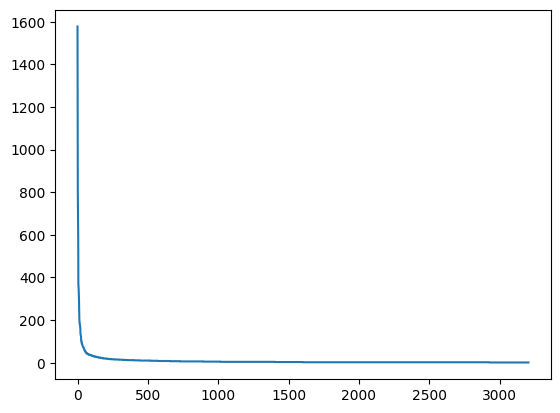

In [51]:
plt.plot(sorted(occurrences.values(),reverse=True))

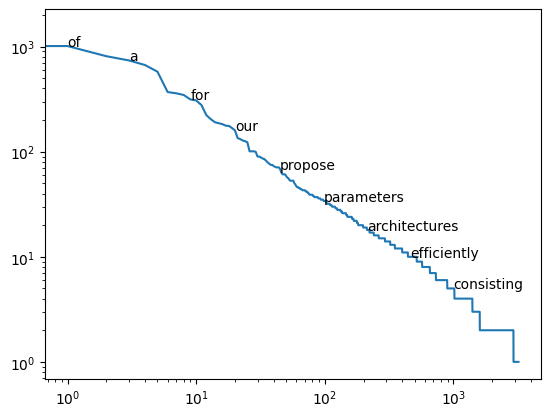

In [52]:
all_counts, all_forms = [], []
for form, count in occurrences.most_common():
    all_counts.append(count)
    all_forms.append(form)
fig,ax = plt.subplots()
ax.plot(all_counts)
ax.set_yscale('log')
ax.set_xscale('log')

for i in torch.logspace(0, torch.log10(torch.tensor(len(all_counts))), 10, dtype=int)-1:
    ax.annotate(all_forms[i], (i, all_counts[i]))

# BPE tokenization
[Byte-Pair Encoding](https://aclanthology.org/P16-1162)

## Pretokenization

To learn BPE we need an initial word vocabulary. For this, use the same code as above but rename `tokenize` in `pretokenize`

In [53]:

class BPETokenizer:
    def __init__(self, V = 1000):
        self.regex = re.compile(r"\w+")
        self.vocabulary = {}
        self.V = V
        self.begin_word = 'Ġ'
        self.merges = []

    def pretokenize(self, text):
        tokens = self.regex.findall(text.lower())
        return tokens

    def tokenize(self, text):
        words = self.pretokenize(text)
        tokens = []
        for word in words:
            word_tokens = [self.begin_word + word[0]] + list(word[1:])
            tokens.extend(word_tokens)
        return tokens

    def encode(self, text):
        tokens = self.tokenize(text)
        return [self.vocabulary[token] for token in tokens if token in self.vocabulary]

    def set_vocab(self, train_texts):
        occurrences = Counter()
        for text in train_texts:
            tokens = self.tokenize(text)
            occurrences.update(tokens)

        most_common = occurrences.most_common(self.V)
        self.vocabulary = {token: idx for idx, (token, _) in enumerate(most_common)}

        return occurrences

In [54]:
bpe_tokenizer = BPETokenizer(V=1000)


In [55]:
occurrences = bpe_tokenizer.set_vocab(train_texts)

In [56]:
bpe_tokenizer.vocabulary

{'e': 0,
 'n': 1,
 'i': 2,
 't': 3,
 'a': 4,
 'o': 5,
 'r': 6,
 's': 7,
 'l': 8,
 'h': 9,
 'c': 10,
 'Ġt': 11,
 'd': 12,
 'u': 13,
 'Ġa': 14,
 'm': 15,
 'g': 16,
 'p': 17,
 'f': 18,
 'Ġo': 19,
 'Ġi': 20,
 'y': 21,
 'Ġs': 22,
 'Ġp': 23,
 'Ġc': 24,
 'v': 25,
 'Ġm': 26,
 'Ġf': 27,
 'Ġw': 28,
 'b': 29,
 'Ġd': 30,
 'Ġe': 31,
 'Ġb': 32,
 'Ġr': 33,
 'w': 34,
 'Ġl': 35,
 'Ġn': 36,
 'k': 37,
 'x': 38,
 'Ġh': 39,
 'Ġu': 40,
 'Ġg': 41,
 'z': 42,
 'Ġv': 43,
 'q': 44,
 'j': 45,
 'Ġq': 46,
 '0': 47,
 'Ġk': 48,
 'Ġ2': 49,
 'Ġ1': 50,
 '2': 51,
 'Ġy': 52,
 '1': 53,
 'Ġj': 54,
 '9': 55,
 '8': 56,
 'Ġ3': 57,
 '4': 58,
 '5': 59,
 'Ġ7': 60,
 'Ġ6': 61,
 '3': 62,
 '7': 63,
 '6': 64,
 'Ġ0': 65,
 'Ġz': 66,
 'Ġ8': 67,
 'Ġ9': 68,
 'Ġx': 69,
 'Ġ4': 70,
 'Ġα': 71,
 'Ġ5': 72,
 'ï': 73}

In [57]:
bpe_tokenizer.merges

[]

In [58]:
bpe_tokenizer.tokenize(train_texts[0])

['Ġw',
 'e',
 'Ġp',
 'r',
 'e',
 's',
 'e',
 'n',
 't',
 'Ġa',
 'Ġm',
 'e',
 't',
 'h',
 'o',
 'd',
 'Ġf',
 'o',
 'r',
 'Ġt',
 'h',
 'e',
 'Ġg',
 'e',
 'n',
 'e',
 'r',
 'a',
 't',
 'i',
 'o',
 'n',
 'Ġo',
 'f',
 'Ġm',
 'i',
 'd',
 'i',
 'Ġf',
 'i',
 'l',
 'e',
 's',
 'Ġo',
 'f',
 'Ġp',
 'i',
 'a',
 'n',
 'o',
 'Ġm',
 'u',
 's',
 'i',
 'c',
 'Ġt',
 'h',
 'e',
 'Ġm',
 'e',
 't',
 'h',
 'o',
 'd',
 'Ġm',
 'o',
 'd',
 'e',
 'l',
 's',
 'Ġt',
 'h',
 'e',
 'Ġr',
 'i',
 'g',
 'h',
 't',
 'Ġa',
 'n',
 'd',
 'Ġl',
 'e',
 'f',
 't',
 'Ġh',
 'a',
 'n',
 'd',
 's',
 'Ġu',
 's',
 'i',
 'n',
 'g',
 'Ġt',
 'w',
 'o',
 'Ġn',
 'e',
 't',
 'w',
 'o',
 'r',
 'k',
 's',
 'Ġw',
 'h',
 'e',
 'r',
 'e',
 'Ġt',
 'h',
 'e',
 'Ġl',
 'e',
 'f',
 't',
 'Ġh',
 'a',
 'n',
 'd',
 'Ġi',
 's',
 'Ġc',
 'o',
 'n',
 'd',
 'i',
 't',
 'i',
 'o',
 'n',
 'e',
 'd',
 'Ġo',
 'n',
 'Ġt',
 'h',
 'e',
 'Ġr',
 'i',
 'g',
 'h',
 't',
 'Ġh',
 'a',
 'n',
 'd',
 'Ġt',
 'h',
 'i',
 's',
 'Ġw',
 'a',
 'y',
 'Ġt',
 'h',
 'e',
 'Ġm',
 '

## Zipf's Law return
Do the same as above with:
- your BPE tokenizer
- the subword tokenizer of [GPT-2](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)





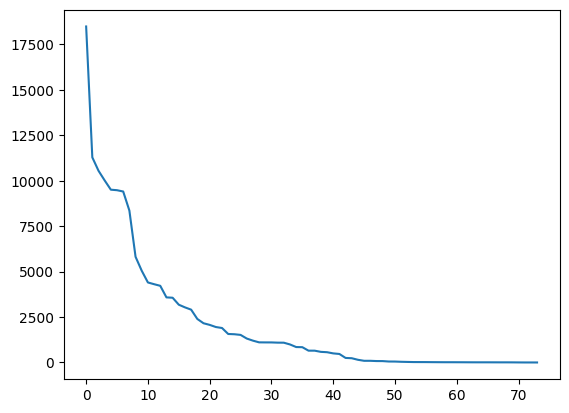

In [59]:
plt.plot(sorted(occurrences.values(),reverse=True))

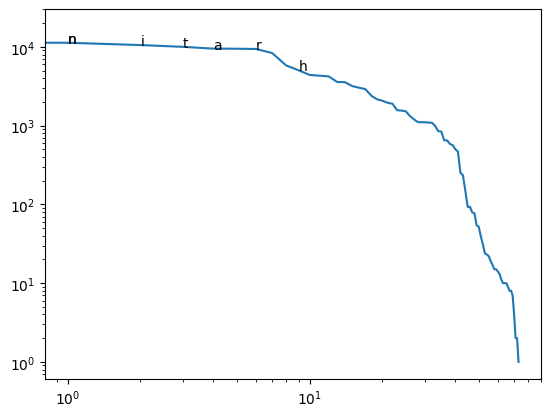

In [60]:
all_counts, all_forms = [], []
for form, count in occurrences.most_common():
    all_counts.append(count)
    all_forms.append("".join(form))
fig,ax = plt.subplots()
ax.plot(all_counts)
ax.set_yscale('log')
ax.set_xscale('log')

for i in torch.logspace(0, torch.log10(torch.tensor(len(all_counts))), 10, dtype=int)-1:
    ax.annotate(all_forms[i], (i, all_counts[i]))

In [62]:
from transformers import AutoTokenizer

gpt_tokenizer = AutoTokenizer.from_pretrained("openai-community/gpt2")
gpt_tokenizer.pad_token = gpt_tokenizer.eos_token

In [63]:
gpt_tokenizer.tokenize(train_texts[0])

['ï',
 '»',
 '¿',
 'We',
 'Ġpresent',
 'Ġa',
 'Ġmethod',
 'Ġfor',
 'Ġthe',
 'Ġgeneration',
 'Ġof',
 'ĠMid',
 'i',
 'Ġfiles',
 'Ġof',
 'Ġpiano',
 'Ġmusic',
 '.',
 'ĠThe',
 'Ġmethod',
 'Ġmodels',
 'Ġthe',
 'Ġright',
 'Ġand',
 'Ġleft',
 'Ġhands',
 'Ġusing',
 'Ġtwo',
 'Ġnetworks',
 ',',
 'Ġwhere',
 'Ġthe',
 'Ġleft',
 'Ġhand',
 'Ġis',
 'Ġconditioned',
 'Ġon',
 'Ġthe',
 'Ġright',
 'Ġhand',
 '.',
 'ĠThis',
 'Ġway',
 ',',
 'Ġthe',
 'Ġmelody',
 'Ġis',
 'Ġgenerated',
 'Ġbefore',
 'Ġthe',
 'Ġharmony',
 '.',
 'ĠThe',
 'ĠMid',
 'i',
 'Ġis',
 'Ġrepresented',
 'Ġin',
 'Ġa',
 'Ġway',
 'Ġthat',
 'Ġis',
 'Ġinvari',
 'ant',
 'Ġto',
 'Ġthe',
 'Ġmusical',
 'Ġscale',
 ',',
 'Ġand',
 'Ġthe',
 'Ġmelody',
 'Ġis',
 'Ġrepresented',
 ',',
 'Ġfor',
 'Ġthe',
 'Ġpurpose',
 'Ġof',
 'Ġconditioning',
 'Ġthe',
 'Ġharmony',
 ',',
 'Ġby',
 'Ġthe',
 'Ġcontent',
 'Ġof',
 'Ġeach',
 'Ġbar',
 ',',
 'Ġviewed',
 'Ġas',
 'Ġa',
 'Ġchord',
 '.',
 'ĠFinally',
 ',',
 'Ġnotes',
 'Ġare',
 'Ġadded',
 'Ġrandomly',
 ',',
 'Ġbased',
 'Ġon'

In [64]:
gpt_tokenizer(train_texts[:4])['input_ids']

[[171,
  119,
  123,
  1135,
  1944,
  257,
  2446,
  329,
  262,
  5270,
  286,
  7215,
  72,
  3696,
  286,
  19132,
  2647,
  13,
  383,
  2446,
  4981,
  262,
  826,
  290,
  1364,
  2832,
  1262,
  734,
  7686,
  11,
  810,
  262,
  1364,
  1021,
  318,
  31964,
  319,
  262,
  826,
  1021,
  13,
  770,
  835,
  11,
  262,
  32859,
  318,
  7560,
  878,
  262,
  22471,
  13,
  383,
  7215,
  72,
  318,
  7997,
  287,
  257,
  835,
  326,
  318,
  25275,
  415,
  284,
  262,
  10530,
  5046,
  11,
  290,
  262,
  32859,
  318,
  7997,
  11,
  329,
  262,
  4007,
  286,
  21143,
  262,
  22471,
  11,
  416,
  262,
  2695,
  286,
  1123,
  2318,
  11,
  9569,
  355,
  257,
  25594,
  13,
  9461,
  11,
  4710,
  389,
  2087,
  15456,
  11,
  1912,
  319,
  428,
  25594,
  10552,
  11,
  287,
  1502,
  284,
  22465,
  262,
  7560,
  6597,
  13,
  3954,
  10256,
  905,
  257,
  2383,
  9025,
  625,
  262,
  1181,
  286,
  262,
  1242,
  329,
  3047,
  319,
  884,
  40522,
  11,
  290,
 

In [65]:
vocab = tokenizer.vocab

In [66]:
len(vocab)

0

In [68]:
print(list(vocab.keys())[:20])


[]


In [67]:
vocab["the"]

KeyError: 'the'

In [69]:
i2token = {i: token for token, i in vocab.items()}
assert len(i2token) == len(vocab)

In [70]:
tokens = gpt_tokenizer(train_texts)['input_ids']

In [71]:
occurrences = Counter()
for token in tokens:
    occurrences += Counter(token)

In [72]:
len(occurrences)

3911

In [74]:
i2token = {idx: token for token, idx in tokenizer.vocabulary.items()}

for index, count in occurrences.most_common(10):
    print(i2token[index], index, count)

modeling 262 1429
this 11 1204
by 13 1170
learning 12 1103
classes 286 980
number 284 758
queens 257 723
techniques 290 656
could 287 450
connected 326 370


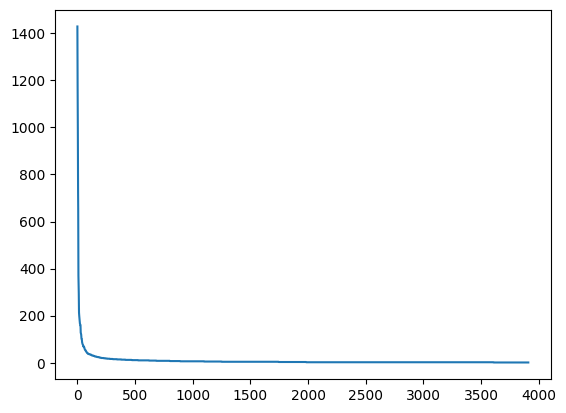

In [75]:
plt.plot(sorted(occurrences.values(),reverse=True))

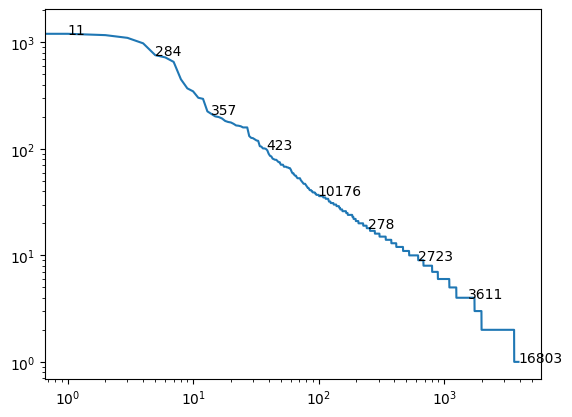

In [79]:
all_counts = torch.tensor(list(occurrences.values()))
i = (-all_counts).argsort()
all_counts=all_counts[i]
all_forms = list(occurrences.keys())
all_forms = [all_forms[j.item()] for j in i]
fig,ax = plt.subplots()
ax.plot(all_counts)
ax.set_yscale('log')
ax.set_xscale('log')

for i in (torch.logspace(0, torch.log10(torch.tensor(len(all_counts))), 10).int() - 1):
    idx = i.item()
    ax.annotate(all_forms[idx], (idx, all_counts[idx]))

# Naive Bayes

In [80]:
class NaiveBayes:
    def __init__(self, V, num_labels):
        self.V = V
        self.num_labels = num_labels
        self.log_priors = torch.zeros(self.num_labels)
        self.log_posteriors = torch.zeros(self.num_labels, self.V)

    def fit(self, train_bow, train_labels):
        num_examples = train_bow.size(0)
        for label in range(self.num_labels):
            self.log_priors[label] = torch.log(
                (train_labels == label).sum().float() / num_examples
            )
        for label in range(self.num_labels):
            docs_label = train_bow[train_labels == label]
            word_counts = docs_label.sum(dim=0) + 1
            self.log_posteriors[label] = torch.log(word_counts / word_counts.sum())

    def predict(self, bow):
        log_probs = bow @ self.log_posteriors.t() + self.log_priors
        return torch.argmax(log_probs, dim=1)

In [83]:
train_bow = torch.tensor(train_bow, dtype=torch.float)
test_bow = torch.tensor(test_bow, dtype=torch.float)

train_labels = torch.tensor(train_labels, dtype=torch.long)
test_labels = torch.tensor(test_labels, dtype=torch.long)

model = NaiveBayes(len(tokenizer.vocabulary), len(train_labels.unique()))

model.fit(train_bow, train_labels)

preds = model.predict(test_bow)

(preds == test_labels).float().mean()

accuracy = (preds == test_labels).float().mean()
print("Accuracy :", accuracy.item())

Accuracy : 0.625


/tmp/ipython-input-2173554037.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_bow = torch.tensor(train_bow, dtype=torch.float)
/tmp/ipython-input-2173554037.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_bow = torch.tensor(test_bow, dtype=torch.float)
/tmp/ipython-input-2173554037.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_labels = torch.tensor(train_labels, dtype=torch.long)
/tmp/ipython-input-2173554037.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().c

# Bonus

Have a look at `sklearn` [CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) combined with [MultinomialNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html), what other parameters haven't we discussed in class? See also [BernoulliNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.BernoulliNB.html).

What about [TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html)? How do you think it could be useful?

You can also try other `sklearn` classifiers using the bag-of-words representation